In [ ]:
#  Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use("seaborn-v0_8")

#  Verify folder structure
print("Main folder files:")
print(os.listdir())

print("\nData folder files:")
print(os.listdir("data"))

#  Load datasets (EXACT filenames from your folder)
fear_greed = pd.read_csv("data/fear_greed.csv.csv")
trades = pd.read_csv("data/hyperliquid_trades.csv")

#  Preview data
print("\nFear & Greed data preview:")
display(fear_greed.head())

print("\nHyperliquid trades data preview:")
display(trades.head())

#  Dataset shapes
print("\nDataset shapes:")
print("Fear & Greed shape:", fear_greed.shape)
print("Trades shape:", trades.shape)


Main folder files:
['analysis.ipynb', 'data', 'README.md']

Data folder files:
['fear_greed.csv.csv', 'hyperliquid_trades.csv']

Fear & Greed data preview:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Hyperliquid trades data preview:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Dataset shapes:
Fear & Greed shape: (2644, 4)
Trades shape: (211224, 16)


In [11]:
print("Fear & Greed dataset")
print("Rows:", fear_greed.shape[0])
print("Columns:", fear_greed.shape[1])

print("\nHyperliquid Trades dataset")
print("Rows:", trades.shape[0])
print("Columns:", trades.shape[1])


Fear & Greed dataset
Rows: 2644
Columns: 4

Hyperliquid Trades dataset
Rows: 211224
Columns: 16


In [12]:
print("Missing values in Fear & Greed:")
print(fear_greed.isnull().sum())

print("\nMissing values in Trades:")
print(trades.isnull().sum())


Missing values in Fear & Greed:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in Trades:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [13]:
# Convert date column to datetime
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

# Create a daily date column (already daily, but for safety)
fear_greed['day'] = fear_greed['date'].dt.date

fear_greed[['date', 'day', 'classification']].head()


,date,day,classification
0,2018-02-01,2018-02-01,Fear
1,2018-02-02,2018-02-02,Extreme Fear
2,2018-02-03,2018-02-03,Fear
3,2018-02-04,2018-02-04,Extreme Fear
4,2018-02-05,2018-02-05,Extreme Fear


In [14]:
# Convert trades timestamp to datetime
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format="%d-%m-%Y %H:%M"
)

# Extract trading day
trades['day'] = trades['Timestamp IST'].dt.date

trades[['Timestamp IST', 'day']].head()


,Timestamp IST,day
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [15]:
print("Fear & Greed date range:")
print(fear_greed['day'].min(), "to", fear_greed['day'].max())

print("\nTrades date range:")
print(trades['day'].min(), "to", trades['day'].max())


Fear & Greed date range:
2018-02-01 to 2025-05-02

Trades date range:
2023-05-01 to 2025-05-01


In [16]:
# Get trade date range
min_trade_day = trades['day'].min()
max_trade_day = trades['day'].max()

# Filter sentiment data
fg_filtered = fear_greed[
    (fear_greed['day'] >= min_trade_day) &
    (fear_greed['day'] <= max_trade_day)
].copy()

print("Filtered Fear & Greed range:")
print(fg_filtered['day'].min(), "to", fg_filtered['day'].max())


Filtered Fear & Greed range:
2023-05-01 to 2025-05-01


In [17]:
# Merge on daily date
trades_merged = trades.merge(
    fg_filtered[['day', 'classification']],
    on='day',
    how='left'
)

trades_merged[['day', 'classification']].head()


,day,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [18]:
print("Missing sentiment labels after merge:")
print(trades_merged['classification'].isnull().sum())


Missing sentiment labels after merge:
6


In [19]:
# Normalize sentiment into 2 buckets
trades_merged['sentiment'] = trades_merged['classification'].replace({
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Extreme Greed': 'Greed',
    'Greed': 'Greed'
})

trades_merged[['classification', 'sentiment']].value_counts()


classification  sentiment
Fear            Fear         61837
Greed           Greed        50303
Extreme Greed   Greed        39992
Neutral         Neutral      37686
Extreme Fear    Fear         21400
Name: count, dtype: int64

In [20]:
daily_pnl = (
    trades_merged
    .groupby(['Account', 'day', 'sentiment'])['Closed PnL']
    .sum()
    .reset_index()
)

daily_pnl.head()


,Account,day,sentiment,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,1603.1


In [21]:
trades_per_day = (
    trades_merged
    .groupby(['Account', 'day', 'sentiment'])
    .size()
    .reset_index(name='num_trades')
)

trades_per_day.head()


,Account,day,sentiment,num_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,27


In [22]:
trades_merged['win'] = trades_merged['Closed PnL'] > 0

win_rate = (
    trades_merged
    .groupby(['Account', 'sentiment'])['win']
    .mean()
    .reset_index(name='win_rate')
)

win_rate.head()


,Account,sentiment,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,0.518104
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,0.102041
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,0.581948
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Fear,0.467407
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Greed,0.440021


In [23]:
long_short = (
    trades_merged
    .groupby(['sentiment', 'Side'])
    .size()
    .reset_index(name='count')
)

long_short


,sentiment,Side,count
0,Fear,BUY,41205
1,Fear,SELL,42032
2,Greed,BUY,42516
3,Greed,SELL,47779
4,Neutral,BUY,18969
5,Neutral,SELL,18717


In [24]:
# Aggregate daily PnL across all traders
daily_sentiment_pnl = (
    daily_pnl
    .groupby('sentiment')['Closed PnL']
    .mean()
    .reset_index()
)

daily_sentiment_pnl


,sentiment,Closed PnL
0,Fear,5185.146443
1,Greed,4144.208334
2,Neutral,3438.618818


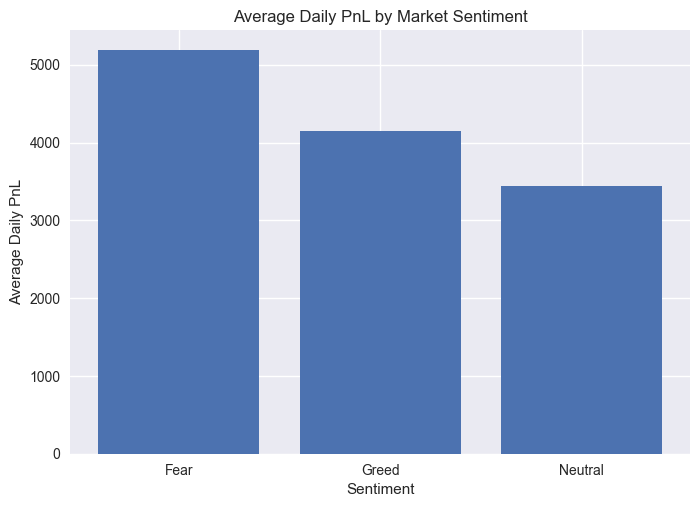

In [25]:
plt.figure()
plt.bar(
    daily_sentiment_pnl['sentiment'],
    daily_sentiment_pnl['Closed PnL']
)
plt.title("Average Daily PnL by Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.xlabel("Sentiment")
plt.show()


In [26]:
sentiment_winrate = (
    trades_merged
    .groupby('sentiment')['win']
    .mean()
    .reset_index()
)

sentiment_winrate


,sentiment,win
0,Fear,0.407871
1,Greed,0.420311
2,Neutral,0.396991


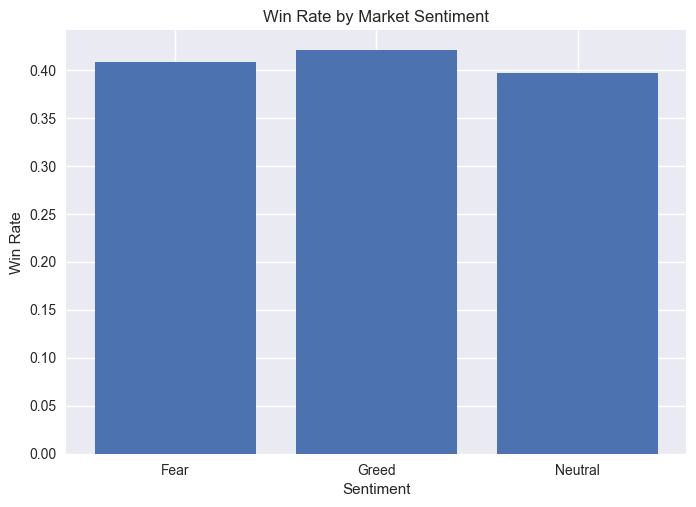

In [27]:
plt.figure()
plt.bar(
    sentiment_winrate['sentiment'],
    sentiment_winrate['win']
)
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.xlabel("Sentiment")
plt.show()


In [28]:
avg_trades = (
    trades_per_day
    .groupby('sentiment')['num_trades']
    .mean()
    .reset_index()
)

avg_trades


,sentiment,num_trades
0,Fear,105.363291
1,Greed,76.912266
2,Neutral,100.228723


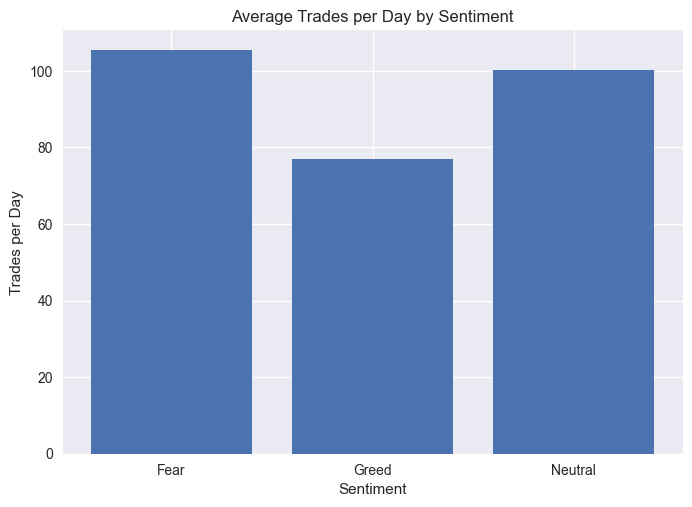

In [29]:
plt.figure()
plt.bar(
    avg_trades['sentiment'],
    avg_trades['num_trades']
)
plt.title("Average Trades per Day by Sentiment")
plt.ylabel("Trades per Day")
plt.xlabel("Sentiment")
plt.show()


In [30]:
long_short_pivot = long_short.pivot(
    index='sentiment',
    columns='Side',
    values='count'
)

long_short_pivot


Side,BUY,SELL
sentiment,,
Fear,41205,42032
Greed,42516,47779
Neutral,18969,18717


In [31]:
trader_activity = (
    trades_per_day
    .groupby('Account')['num_trades']
    .mean()
    .reset_index(name='avg_trades_per_day')
)

trader_activity.head()


,Account,avg_trades_per_day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,159.083333
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,140.000000
2,0x271b280974205ca63b716753467d5a371de622ab,317.416667
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,82.166667
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,46.942029


In [32]:
threshold = trader_activity['avg_trades_per_day'].median()

trader_activity['frequency_segment'] = np.where(
    trader_activity['avg_trades_per_day'] >= threshold,
    'Frequent',
    'Infrequent'
)

trader_activity['frequency_segment'].value_counts()


frequency_segment
Frequent      16
Infrequent    16
Name: count, dtype: int64

In [33]:
trades_segmented = trades_merged.merge(
    trader_activity[['Account', 'frequency_segment']],
    on='Account',
    how='left'
)

trades_segmented[['Account', 'frequency_segment']].head()


,Account,frequency_segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent


In [34]:
segment_perf = (
    trades_segmented
    .groupby(['frequency_segment', 'sentiment'])['Closed PnL']
    .mean()
    .reset_index()
)

segment_perf


,frequency_segment,sentiment,Closed PnL
0,Frequent,Fear,44.227385
1,Frequent,Greed,37.380233
2,Frequent,Neutral,24.398635
3,Infrequent,Fear,74.679559
4,Infrequent,Greed,93.191622
5,Infrequent,Neutral,63.358856


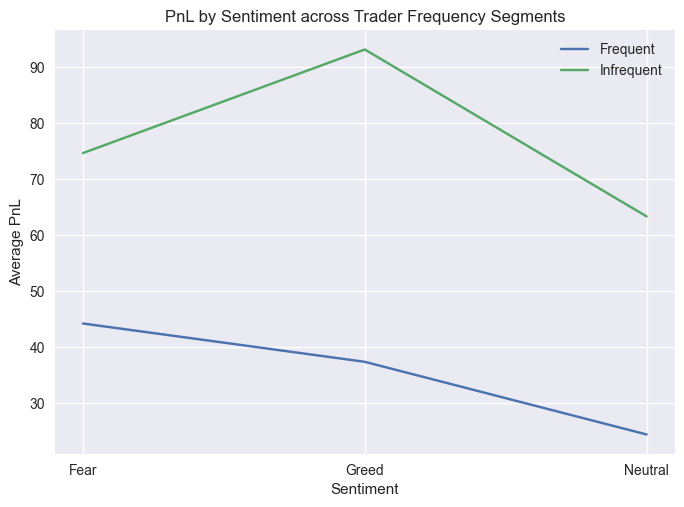

In [35]:
plt.figure()
for seg in segment_perf['frequency_segment'].unique():
    data = segment_perf[segment_perf['frequency_segment'] == seg]
    plt.plot(data['sentiment'], data['Closed PnL'], label=seg)

plt.title("PnL by Sentiment across Trader Frequency Segments")
plt.ylabel("Average PnL")
plt.xlabel("Sentiment")
plt.legend()
plt.show()


In [36]:
pnl_stats = (
    daily_pnl
    .groupby('Account')['Closed PnL']
    .agg(['mean', 'std'])
    .reset_index()
)

pnl_stats.head()


,Account,mean,std
0,0x083384f897ee0f19899168e3b1bec365f52a9012,66676.242499,150401.797346
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,920.871548,3603.042291
2,0x271b280974205ca63b716753467d5a371de622ab,-5869.682610,33420.410014
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,817.684040,2993.284702
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2444.318913,4867.743469


In [37]:
pnl_stats['cv'] = pnl_stats['std'] / pnl_stats['mean'].abs()

threshold = pnl_stats['cv'].median()

pnl_stats['consistency_segment'] = np.where(
    pnl_stats['cv'] <= threshold,
    'Consistent',
    'Inconsistent'
)

pnl_stats['consistency_segment'].value_counts()


consistency_segment
Consistent      16
Inconsistent    16
Name: count, dtype: int64

In [38]:
trades_consistent = trades_merged.merge(
    pnl_stats[['Account', 'consistency_segment']],
    on='Account',
    how='left'
)

consistency_perf = (
    trades_consistent
    .groupby(['consistency_segment', 'sentiment'])['Closed PnL']
    .mean()
    .reset_index()
)

consistency_perf


,consistency_segment,sentiment,Closed PnL
0,Consistent,Fear,84.178627
1,Consistent,Greed,54.669965
2,Consistent,Neutral,51.257864
3,Inconsistent,Fear,20.869496
4,Inconsistent,Greed,53.420555
5,Inconsistent,Neutral,20.585474
